# Classificador de Qualidade de Lances de Xadrez

**Disciplina:** Paradigmas de Aprendizagem de Máquina  

---

## Sobre este Notebook

Este é o **notebook principal** (orquestrador) do projeto. Ele apresenta os resultados de uma versão selecionada usando dados pré-computados.

- Para **re-executar o pipeline** (download, filtragem, rotulagem, treino), use os notebooks por versão: `v1_posicional.ipynb`, `v2_tatica.ipynb`, `v3_lookahead.ipynb`.
- Para **comparar as 3 versões** lado a lado, use `comparacao.ipynb`.
- Para **mudar a versão** apresentada aqui, altere `config = V3` na célula de configuração.

### Versões do pipeline

| Versão | Features | Descrição |
|--------|----------|-----------|
| **V1** | 33 posicionais | Material, mobilidade, segurança do rei, estrutura de peões, controle do centro |
| **V2** | 52 (33 + 19 táticas) | V1 + peças indefesas, capturas com ganho, cravadas, rei avançado, tensão |
| **V3** | 67 (52 + 15 look-ahead) | V2 + deltas antes/depois, resposta do adversário, Static Exchange Evaluation (SEE) |

### Abordagem resumida

| Etapa | Método |
|-------|--------|
| Dados | Partidas reais do Lichess (CC0), filtradas por rating e tempo |
| Rotulagem | Avaliação posicional via Stockfish (depth 15): bom (≥ −50 cp), ruim (≤ −150 cp) |
| Features | 33 → 52 → 67 features extraídas com `python-chess` |
| Modelos | Decision Tree + Random Forest, com `class_weight="balanced"` |
| Métricas | Foco em recall e F1 da classe "ruim" — detectar erros é o objetivo |

In [61]:
import json
import os
import random
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*", category=UserWarning)
plt.rcParams.update({"font.size": 11, "figure.facecolor": "white"})
sns.set_style("whitegrid")

def _find_project_root() -> Path:
    """Walk up until we find src/version_config.py (unique project marker)."""
    # __vsc_ipynb_file__ is injected by VS Code / Cursor into notebook kernels
    nb_file = globals().get("__vsc_ipynb_file__")
    if nb_file:
        anchor = Path(nb_file).resolve().parent
    else:
        anchor = Path.cwd()
    for candidate in [anchor, *anchor.parents]:
        if (candidate / "src" / "version_config.py").is_file():
            return candidate
    raise FileNotFoundError("Could not find project root (src/version_config.py)")

PROJECT_ROOT = _find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

DATA_DIR = Path("data")

for _mod in ["version_config", "notebook_utils"]:
    sys.modules.pop(_mod, None)
from version_config import V1, V2, V3, ALL_VERSIONS
from notebook_utils import *

print(f"Diretório de trabalho: {os.getcwd()}")
print("Setup OK")

Diretório de trabalho: /Users/noel/Faculdade/ML/Chess
Setup OK


In [62]:
config = V3

print(f"Versão selecionada: {config.label}")
print(f"Features CSV      : {config.features_csv}")
print(f"Modelos           : {config.models_dir}")
print(f"Avaliação         : {config.eval_dir}")

Versão selecionada: V3 — posicional + tática + look-ahead (67 features)
Features CSV      : data/features/features_v3.csv
Modelos           : data/models_v3
Avaliação         : data/evaluation_v3


---

## 2. Coleta e Descrição dos Dados

### Fonte

Os dados vêm da **Lichess open database** ([database.lichess.org](https://database.lichess.org)), sob licença **CC0** (domínio público).

- **Ficheiro:** `lichess_db_standard_rated_2015-01.pgn.zst` (~272 MiB comprimido)

### Filtros aplicados

| Filtro | Critério | Justificativa |
|--------|----------|---------------|
| Rating | Ambos 1400–1700 (Lichess) | Faixa-alvo equivalente a 1200–1500 Chess.com |
| Tempo | Blitz/Rapid (3–10 min) | Jogos sérios mas com pressão temporal |
| Término | Normal (mate/resignação) | Evitar jogos decididos por timeout |
| Variante | Standard | Sem Chess960 etc. |
| Fase | Lances 8 a 40 | Meio-jogo |
| Amostragem | 10% das partidas válidas | Controle de volume, seed=42 |

In [63]:
df_filtered = pd.read_csv(DATA_DIR / "filtered" / "moves_filtered.csv")
print_dataset_stats(df_filtered)
print()
df_filtered.head()

  DATASET FILTRADO
  Partidas       : 2,911
  Lances (total) : 136,620
  Lances/partida : 46.9
  Colunas        : ['game_id', 'game_site', 'white_elo', 'black_elo', 'time_control', 'result', 'move_number', 'color', 'fen_before', 'move_uci', 'move_san']



,game_id,game_site,white_elo,black_elo,time_control,result,move_number,color,fen_before,move_uci,move_san
0,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,8,white,r2qk1nr/pbpp1pbp/1p4p1/3Pp3/1n2P3/2NBBN2/PPP2P...,d3e2,Be2
1,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,8,black,r2qk1nr/pbpp1pbp/1p4p1/3Pp3/1n2P3/2N1BN2/PPP1B...,g8e7,Ne7
2,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,9,white,r2qk2r/pbppnpbp/1p4p1/3Pp3/1n2P3/2N1BN2/PPP1BP...,a2a3,a3
3,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,9,black,r2qk2r/pbppnpbp/1p4p1/3Pp3/1n2P3/P1N1BN2/1PP1B...,b4a6,Na6
4,1,https://lichess.org/GR3wmiDi,1454,1602,300+0,0-1,10,white,r2qk2r/pbppnpbp/np4p1/3Pp3/4P3/P1N1BN2/1PP1BPP...,d1d2,Qd2


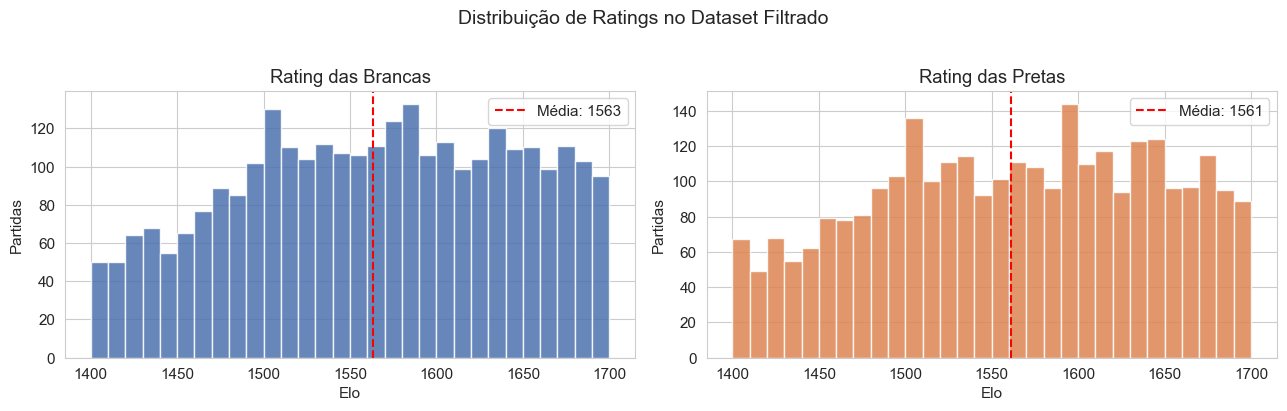

In [64]:
plot_rating_distribution(df_filtered)

---

## 3. Rotulagem via Stockfish

$$\delta = \text{eval\_depois} - \text{eval\_antes}$$

| Classe | Condição | Significado |
|--------|----------|-------------|
| **Bom** | δ ≥ −50 cp | Perda ≤ 0.5 peão |
| **Descartado** | −150 < δ < −50 | Zona cinzenta |
| **Ruim** | δ ≤ −150 cp | Perda ≥ 1.5 peão |

In [65]:
df_scored = pd.read_csv(DATA_DIR / "labeled" / "moves_all_scored.csv")
df_labeled = pd.read_csv(DATA_DIR / "labeled" / "moves_labeled.csv")
print_labeling_stats(df_scored, df_labeled)

  ROTULAGEM
  Lances avaliados      : 136,620
  Bom (δ ≥ −50 cp)      : 92,197 (67.5%)
  Descartado (cinzenta) : 27,330 (20.0%)
  Ruim (δ ≤ −150 cp)    : 17,093 (12.5%)
  ──────────────────────
  Dataset final         : 109,290 (bom + ruim)
  Ratio bom:ruim        : 5.39:1


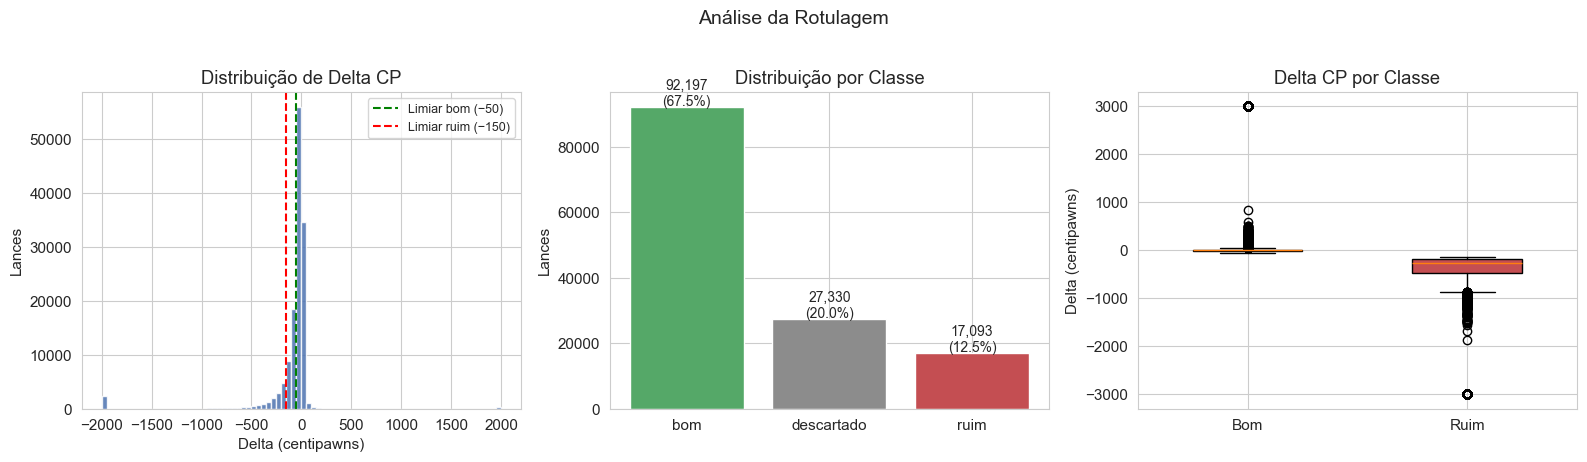

In [66]:
plot_labeling_analysis(df_scored, df_labeled)

---

## 4. Engenharia de Features

In [67]:
df_features = pd.read_csv(config.features_csv)
feature_cols = [c for c in df_features.columns if c != "label"]
print_features_stats(df_features, config)
print(f"\nEstatísticas descritivas:")
df_features[feature_cols].describe().round(2)

  FEATURES — V3
  Fonte       : data/features/features_v3.csv
  Linhas      : 109,290
  Features    : 67
  Valores nulos: 0

Distribuição do label:
label
bom     92197
ruim    17093

Estatísticas descritivas:


,white_pawns,white_knights,white_bishops,white_rooks,white_queens,black_pawns,black_knights,black_bishops,black_rooks,black_queens,...,delta_mobility_opponent,delta_contested_squares,delta_king_attackers_player,opponent_best_capture_value,opponent_can_check,opponent_num_good_captures,created_hanging_self,see_of_move,worst_see_against_player,is_losing_capture
count,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,...,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00,109290.00
mean,5.99,0.98,1.05,1.67,0.70,6.00,0.97,1.08,1.66,0.70,...,-0.74,0.00,-0.09,2.00,0.46,0.26,0.07,0.50,-0.86,0.02
std,1.44,0.77,0.77,0.59,0.46,1.44,0.78,0.76,0.60,0.46,...,13.88,2.22,0.48,1.98,0.50,0.56,0.26,1.55,1.77,0.13
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,-61.00,-16.00,-5.00,0.00,0.00,0.00,0.00,-8.00,-9.00,0.00
25%,5.00,0.00,0.00,1.00,0.00,5.00,0.00,0.00,1.00,0.00,...,-2.00,-1.00,0.00,1.00,0.00,0.00,0.00,0.00,-1.00,0.00
50%,6.00,1.00,1.00,2.00,1.00,6.00,1.00,1.00,2.00,1.00,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7.00,2.00,2.00,2.00,1.00,7.00,2.00,2.00,2.00,1.00,...,0.00,1.00,0.00,3.00,1.00,0.00,0.00,0.00,0.00,0.00
max,8.00,2.00,2.00,2.00,2.00,8.00,3.00,2.00,3.00,2.00,...,65.00,12.00,5.00,9.00,1.00,9.00,1.00,9.00,0.00,1.00


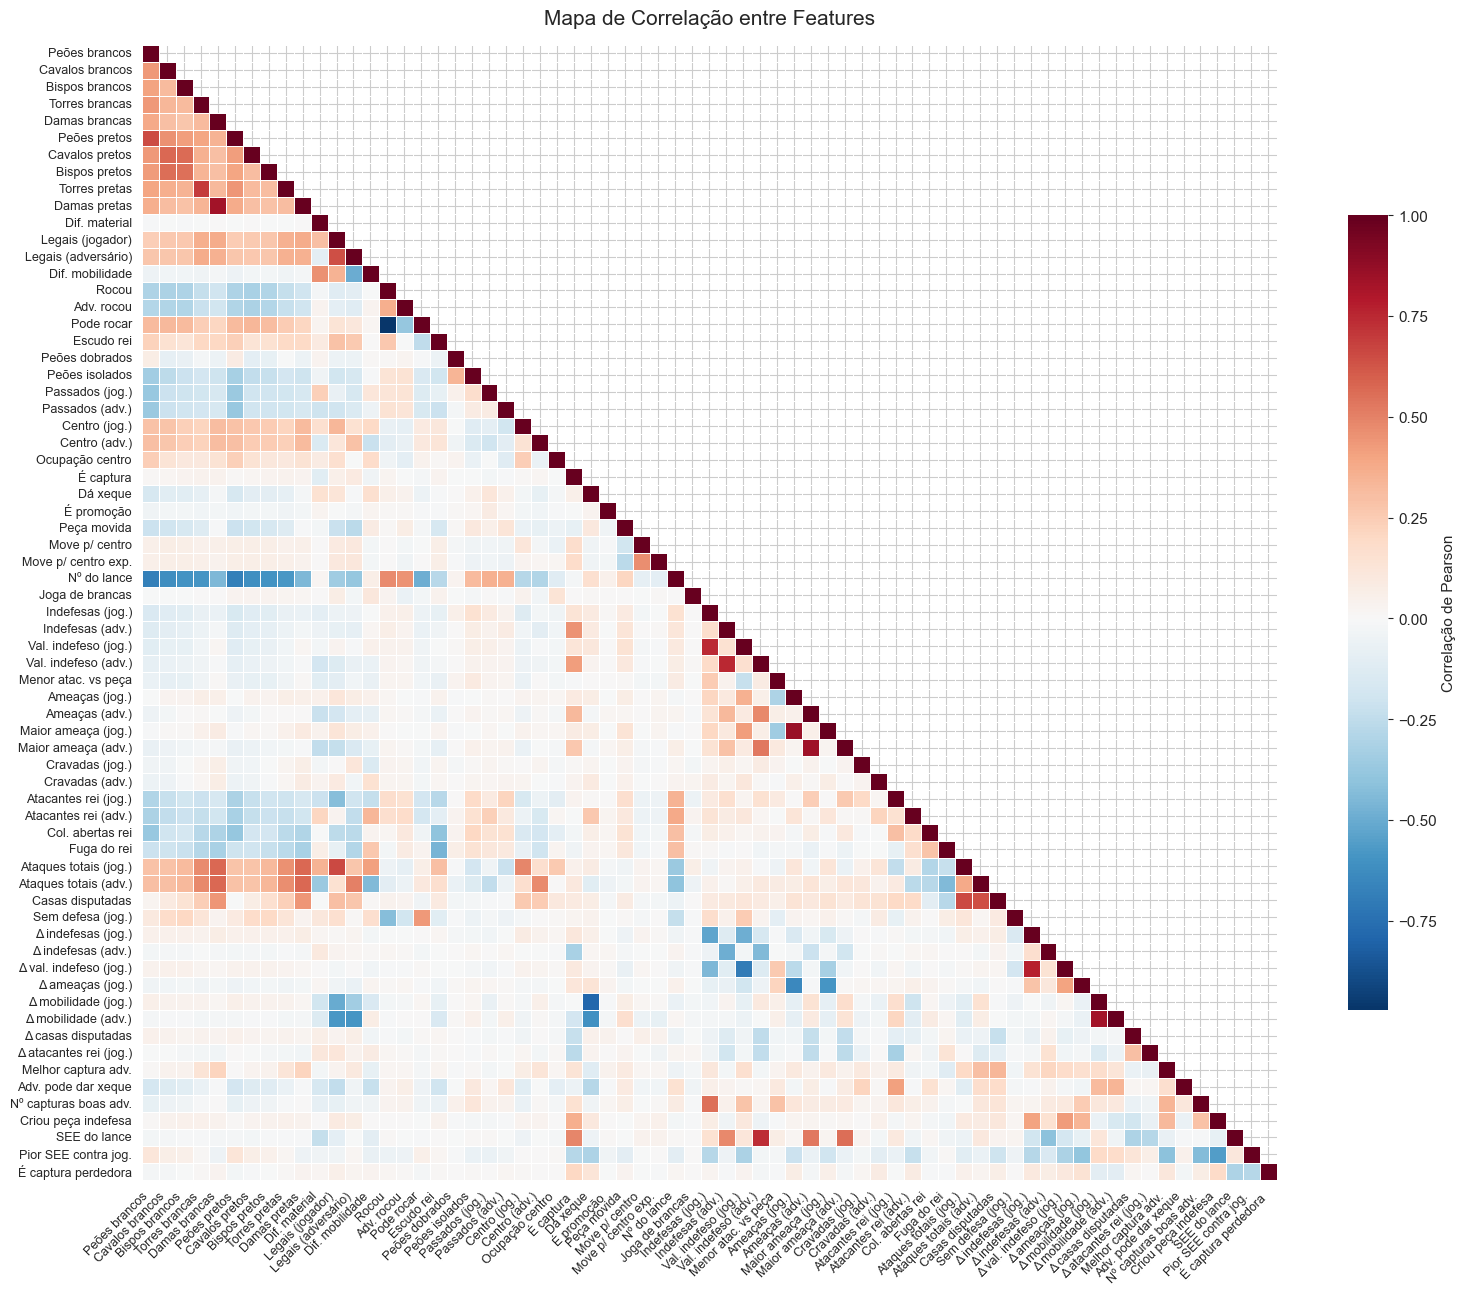

Pares com |correlação| > 0.7:
  Rocou                      ↔  Pode rocar                 r = -0.970
  Ameaças (jog.)             ↔  Maior ameaça (jog.)        r = +0.857
  Ameaças (adv.)             ↔  Maior ameaça (adv.)        r = +0.842
  Damas brancas              ↔  Damas pretas               r = +0.836
  Δ mobilidade (jog.)        ↔  Δ mobilidade (adv.)        r = +0.831
  Dá xeque                   ↔  Δ mobilidade (jog.)        r = -0.792
  Δ indefesas (jog.)         ↔  Δ val. indefeso (jog.)     r = +0.770
  Indefesas (adv.)           ↔  Val. indefeso (adv.)       r = +0.753
  Indefesas (jog.)           ↔  Val. indefeso (jog.)       r = +0.740
  Val. indefeso (adv.)       ↔  SEE do lance               r = +0.731


In [68]:
plot_correlation_matrix(df_features, feature_cols)

---

## 5. Treino dos Modelos

Split **70/15/15** (treino/validação/teste) com estratificação. `class_weight="balanced"`. `GridSearchCV` com 5 folds, métrica F1 da classe "ruim".

In [69]:
X = df_features.drop(columns=["label"])
y = (df_features["label"] == "ruim").astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=RANDOM_SEED
)

print_split_info(X_train, y_train, X_val, y_val, X_test, y_test)

  SPLIT DOS DADOS
  Treino    : 76,546 amostras  (bom=64,574, ruim=11,972, 15.6% ruim)
  Validação : 16,350 amostras  (bom=13,793, ruim=2,557, 15.6% ruim)
  Teste     : 16,394 amostras  (bom=13,830, ruim=2,564, 15.6% ruim)


In [70]:
dt, rf, feature_names = config.load_models()
print_model_params(dt, rf, config)


  DECISION TREE V3 — Melhores hiperparâmetros
  criterion        : entropy
  max_depth        : 10
  min_samples_leaf : 20
  class_weight     : balanced

  RANDOM FOREST V3 — Melhores hiperparâmetros
  n_estimators     : 200
  max_depth        : 15
  min_samples_leaf : 10
  class_weight     : balanced


---

## 6. Avaliação

In [71]:
print_classification_reports(dt, rf, X_test, y_test)

  DECISION TREE — Classification Report
              precision    recall  f1-score   support

         bom       0.91      0.68      0.78     13830
        ruim       0.27      0.64      0.38      2564

    accuracy                           0.68     16394
   macro avg       0.59      0.66      0.58     16394
weighted avg       0.81      0.68      0.72     16394

  RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

         bom       0.90      0.83      0.87     13830
        ruim       0.37      0.52      0.43      2564

    accuracy                           0.78     16394
   macro avg       0.64      0.68      0.65     16394
weighted avg       0.82      0.78      0.80     16394



In [72]:
df_results = build_results_table(dt, rf, X_test, y_test)
print("Tabela comparativa — Conjunto de teste:\n")
df_results

Tabela comparativa — Conjunto de teste:



,Modelo,Accuracy,F1 (bom),F1 (ruim),Recall (ruim),Precision (ruim),ROC-AUC
0,Decision Tree,0.6762,0.7806,0.3821,0.6400,0.2723,0.7176
1,Random Forest,0.7849,0.8673,0.4312,0.5215,0.3676,0.7678


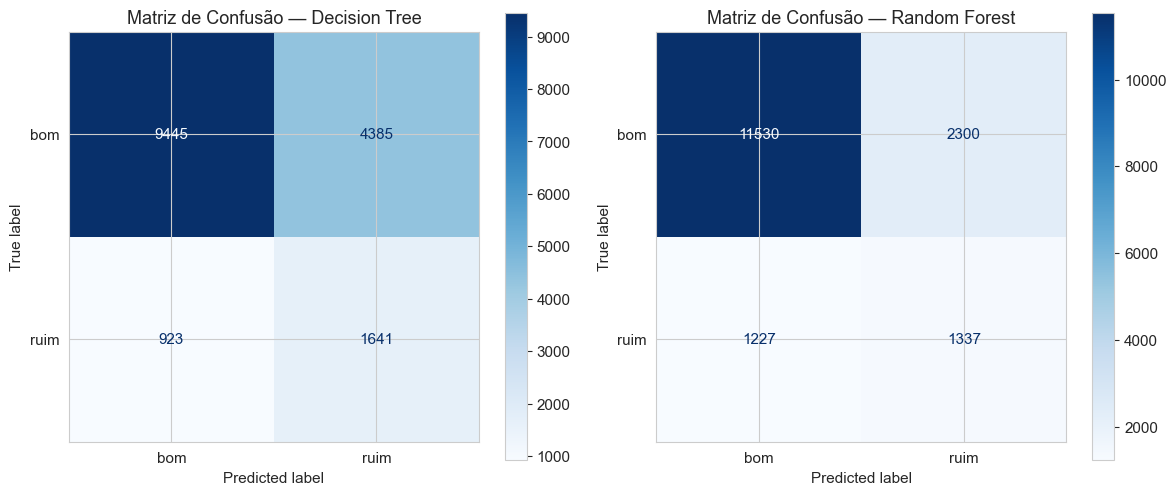

In [73]:
plot_confusion_matrices(dt, rf, X_test, y_test)

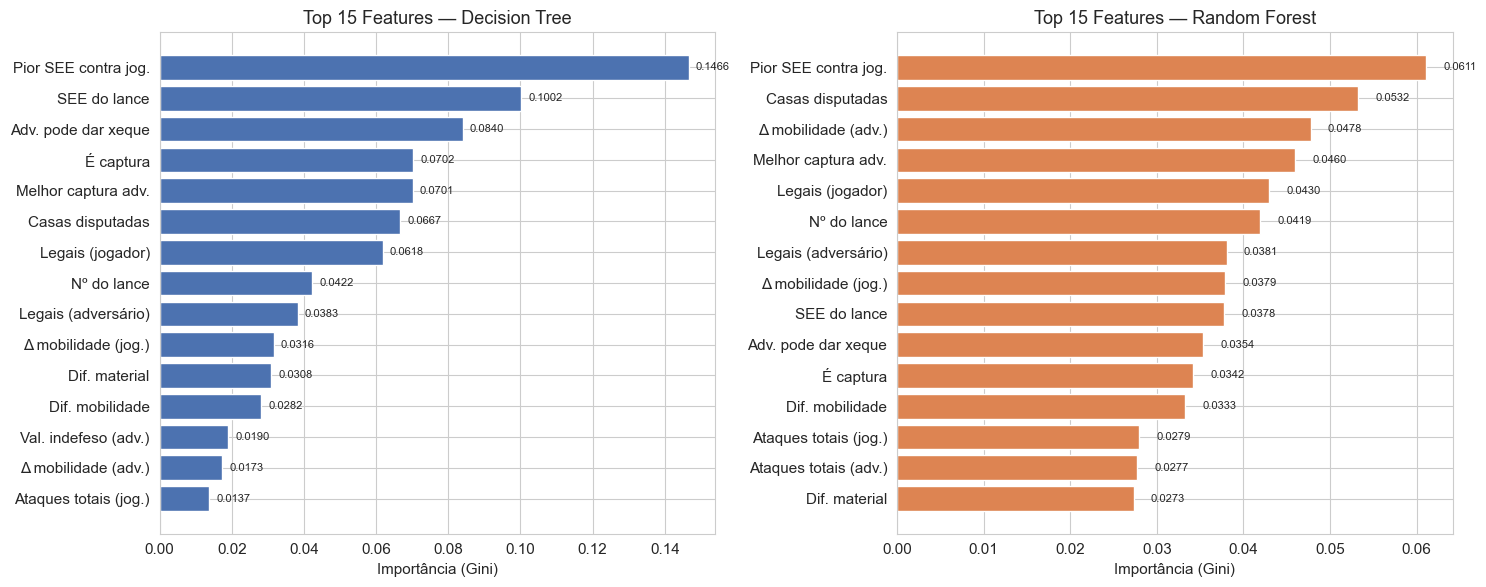

In [74]:
plot_feature_importances_side_by_side(dt, rf, feature_names)

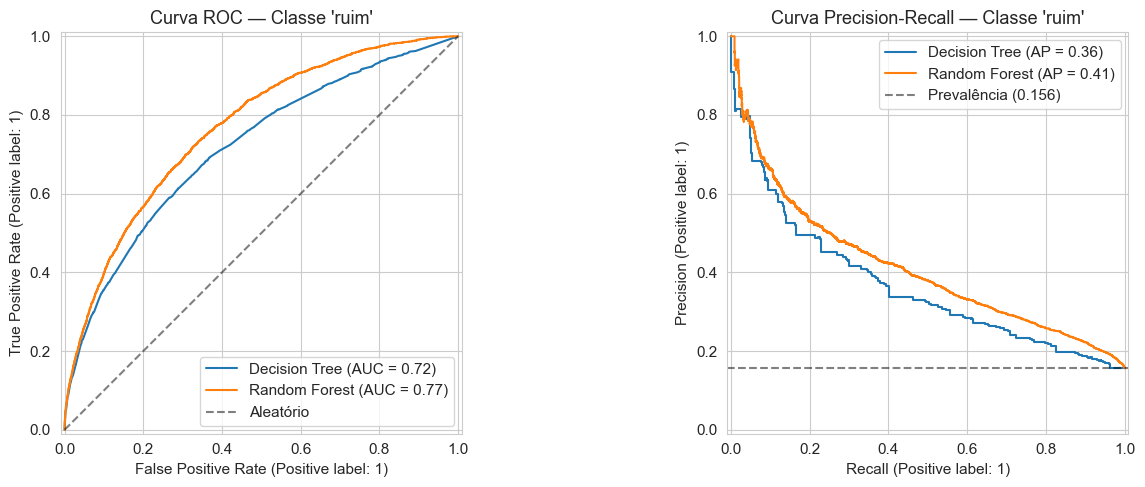

In [75]:
plot_roc_pr_curves(dt, rf, X_test, y_test)

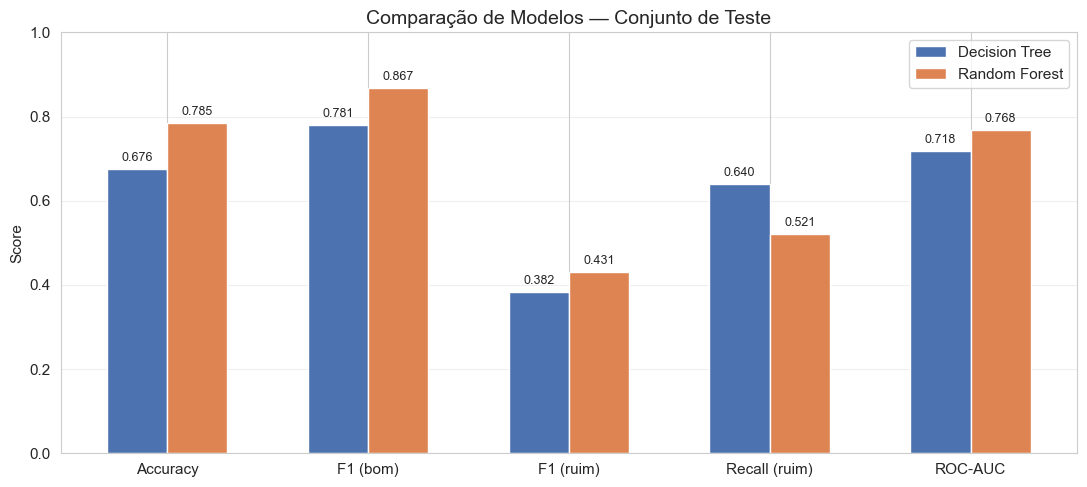

In [76]:
plot_metrics_comparison(dt, rf, X_test, y_test)

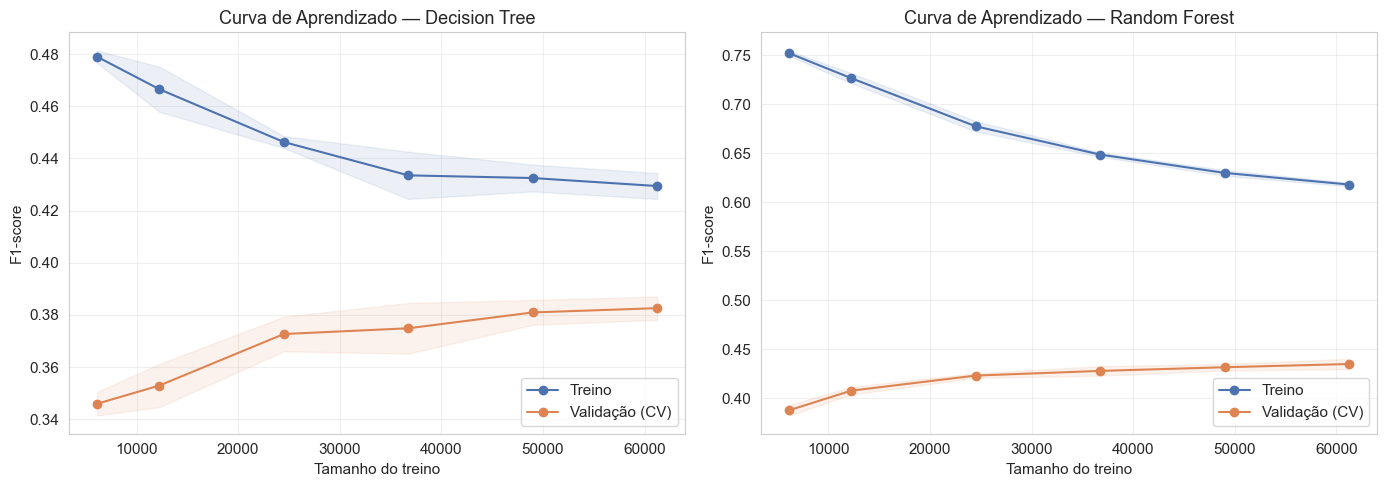

In [77]:
plot_learning_curves(dt, rf, X_train, y_train)

---

## 7. Comparação com Versões Anteriores

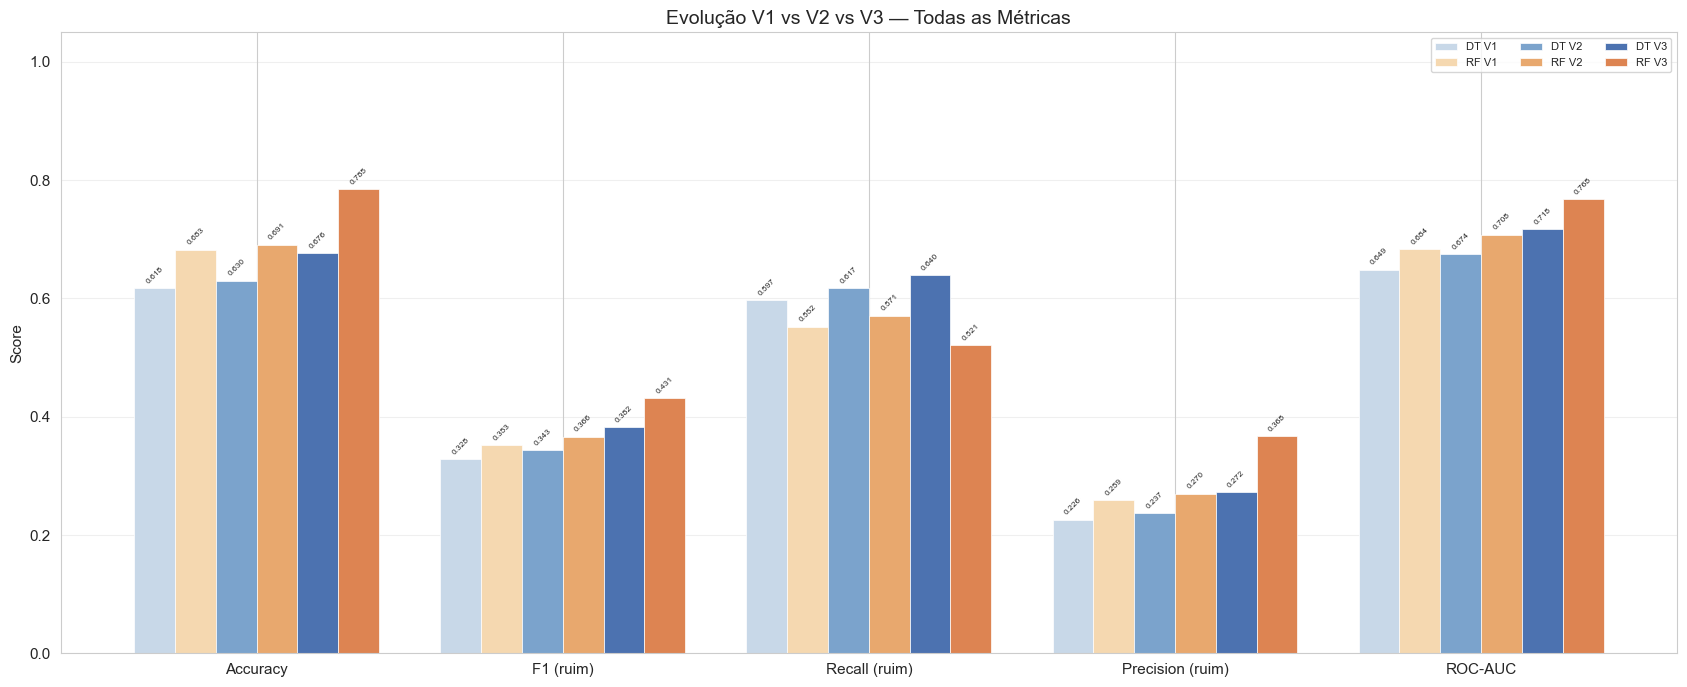

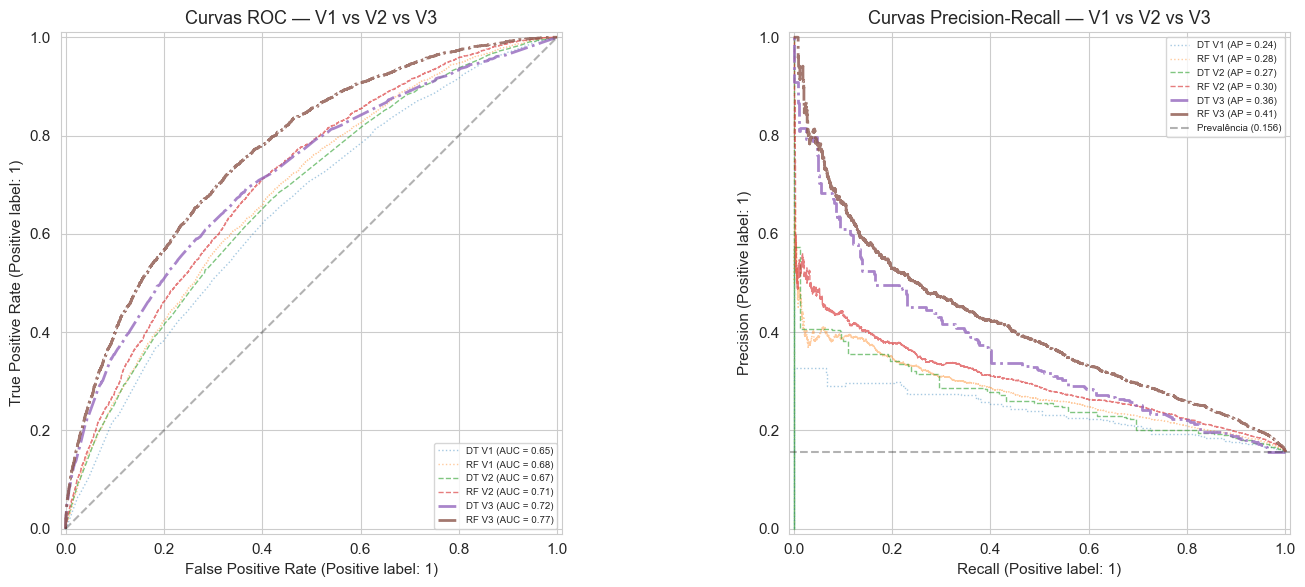

In [78]:
prior_configs = config.prior_versions
if prior_configs:
    all_configs = prior_configs + [config]
    plot_version_metrics_bars(all_configs, X_test, y_test)
    plot_version_roc_pr_overlay(all_configs, X_test, y_test)
else:
    print("V1 não tem versões anteriores para comparar.")

---

## 8. Diagnóstico

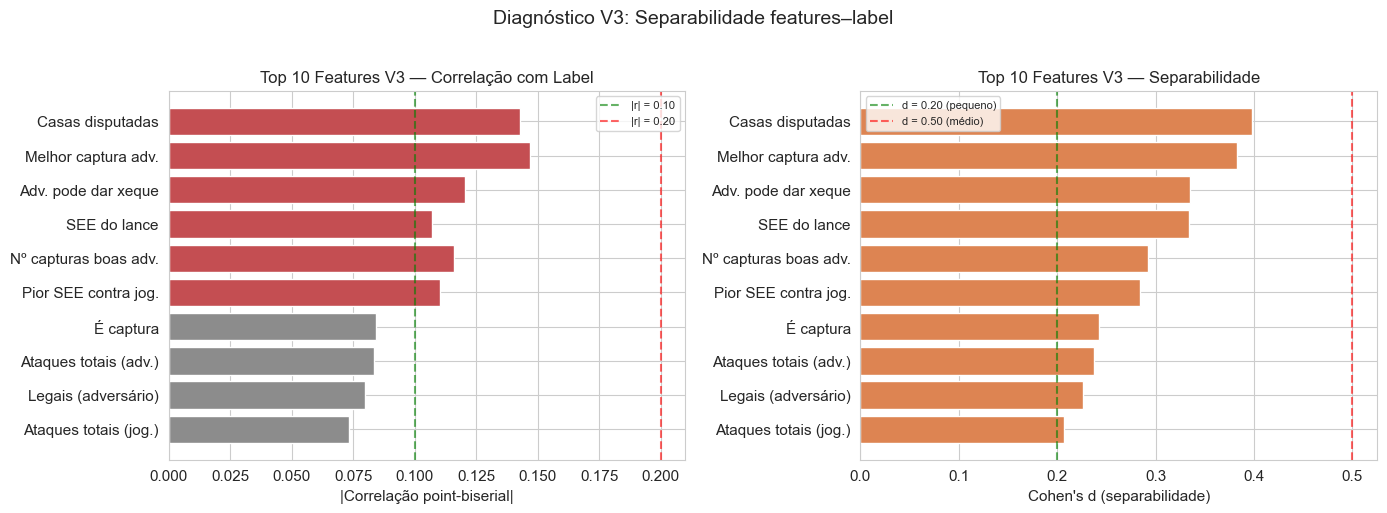

Melhor feature: contested_squares → |r| = 0.143, Cohen's d = 0.398
Features com |r| ≥ 0.10: 6


In [79]:
plot_diagnostic(df_features, feature_cols, f"V{config.version}")

---

## 9. Interpretação

### Regras da Árvore de Decisão

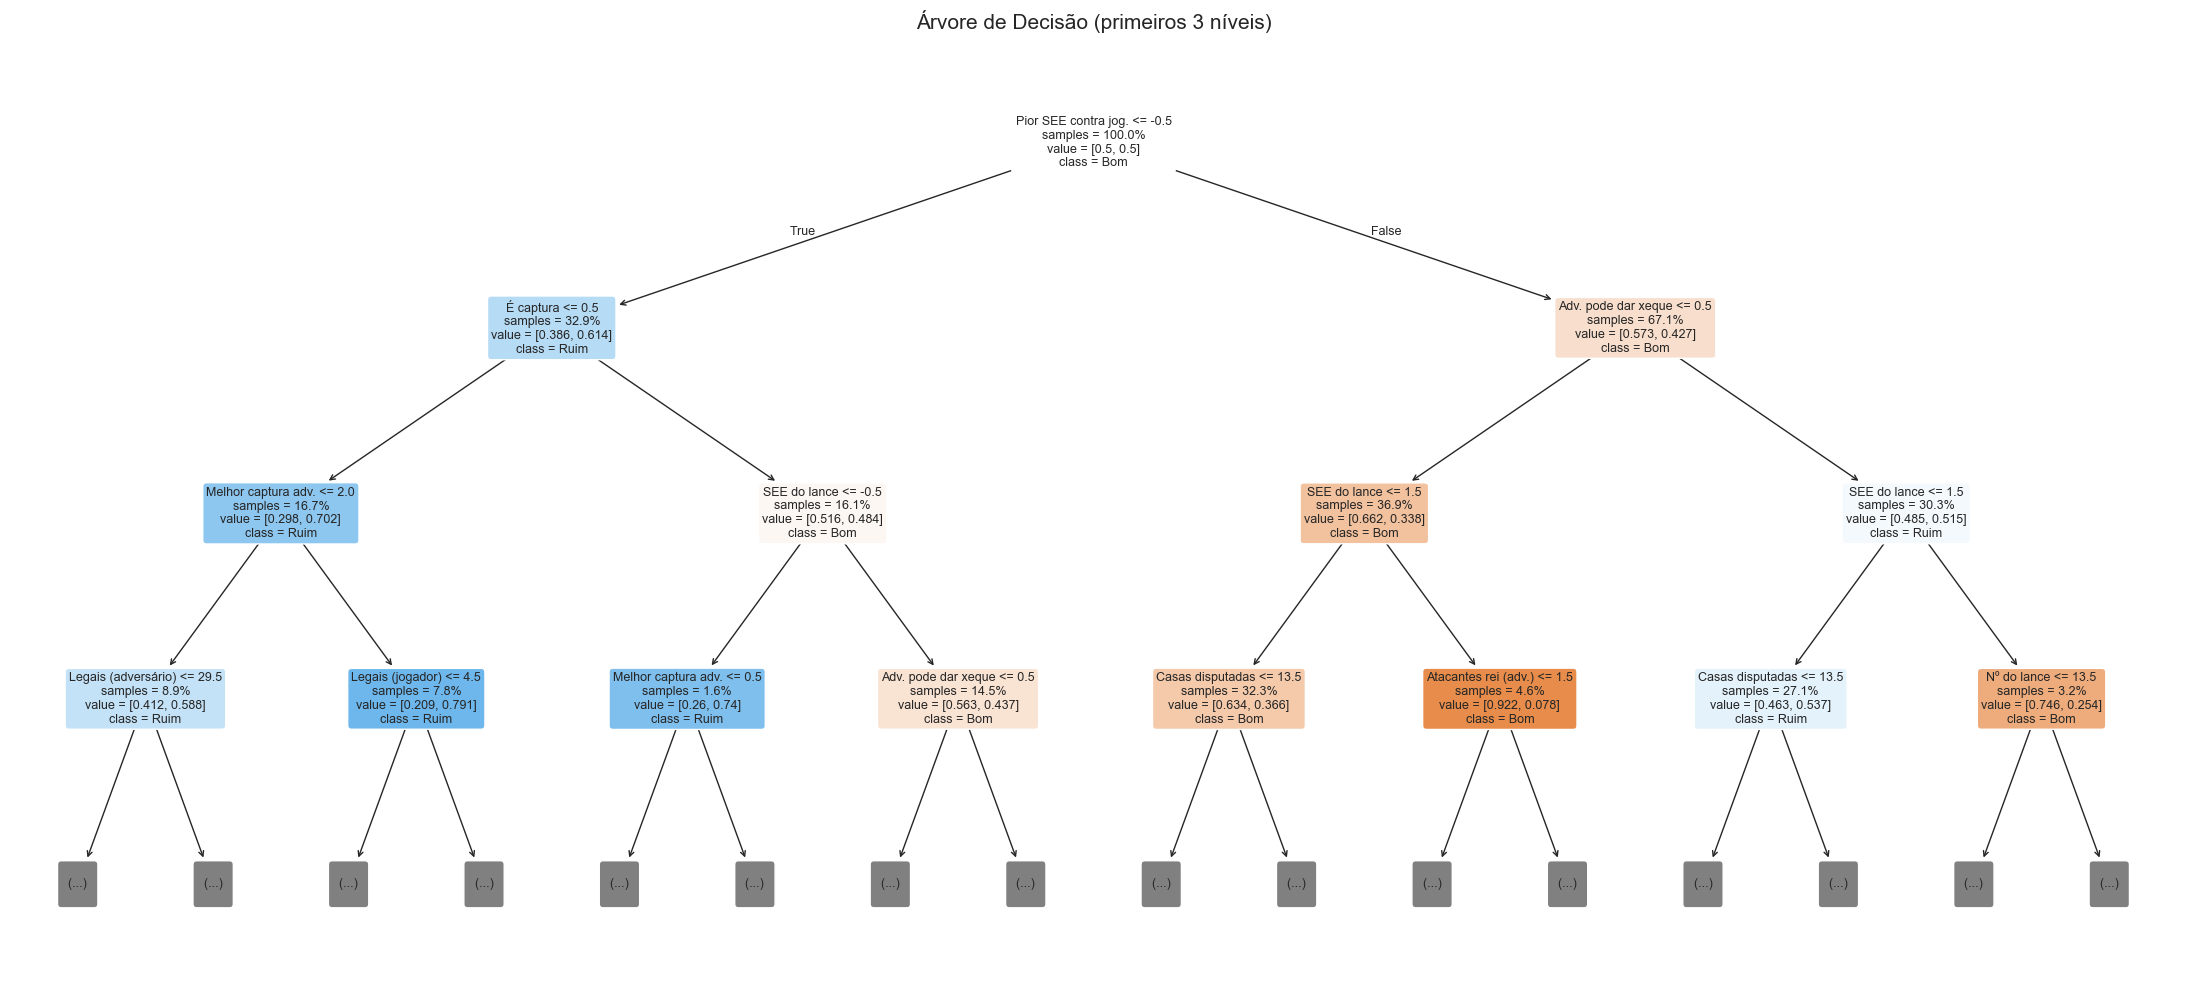

In [80]:
plot_decision_tree(dt, feature_names)

In [81]:
print_tree_rules(config)

═══════════════════════════════════════════════════════════
Regras da Árvore de Decisão V3 — Traduzidas para xadrez
═══════════════════════════════════════════════════════════

Legenda:
  - Δ = delta (diferença antes→depois do lance)
  - "Pior SEE contra jogador": pior resultado de troca de peças
  - "SEE do lance": resultado da sequência de capturas no destino
  - "Melhor captura adversário": valor da melhor captura disponível
  - "Adversário pode dar xeque": 1 se o lance permite xeque
  - Demais features: ver legenda V1/V2

═══════════════════════════════════════════════════════════

|--- Pior SEE contra jogador <= -0.50
|   |--- É captura <= 0.50
|   |   |--- Melhor captura adversário <= 2.00
|   |   |   |--- Lances legais (adversário) <= 29.50
|   |   |   |   |--- Dá xeque <= 0.50
|   |   |   |   |   |--- Diferença material <= -2.50
|   |   |   |   |   |   |--- truncated branch of depth 5
|   |   |   |   |   |--- Diferença material >  -2.50
|   |   |   |   |   |   |--- truncated br

### Análise de Erros

In [82]:
show_error_examples(config)


  FALSOS POSITIVOS — Decision Tree V3
  (modelo disse "ruim", lance é bom)

  FP-1: Qd5 (lance #18, black)
    Delta: -6 cp | Partida: https://lichess.org/bRkKD0xN
    Features: Pior SEE contra jog.=0; SEE do lance=0; Adv. pode dar xeque=1; É captura=0; Melhor captura adv.=1

  FP-2: Qd6 (lance #24, black)
    Delta: -37 cp | Partida: https://lichess.org/tPBLHgbz
    Features: Pior SEE contra jog.=0; SEE do lance=0; Adv. pode dar xeque=1; É captura=0; Melhor captura adv.=3

  FP-3: Qd6+ (lance #39, black)
    Delta: -21 cp | Partida: https://lichess.org/lGGH9i2U
    Features: Pior SEE contra jog.=-1; SEE do lance=0; Adv. pode dar xeque=0; É captura=0; Melhor captura adv.=0

  FP-4: b6 (lance #19, black)
    Delta: -19 cp | Partida: https://lichess.org/yARNnTof
    Features: Pior SEE contra jog.=0; SEE do lance=0; Adv. pode dar xeque=1; É captura=0; Melhor captura adv.=1

  FP-5: Rhg1 (lance #30, white)
    Delta: 31 cp | Partida: https://lichess.org/XeWcCAqg
    Features: Pior SEE con

---

### Demonstração: Classificador em Ação

Até aqui, avaliámos o modelo com métricas agregadas (F1, ROC-AUC, etc.). Agora vamos ver o classificador **a funcionar numa posição real**: dada uma posição de uma partida do dataset, o modelo avalia **todos os lances legais** e classifica cada um como bom ou ruim.

O cenário demonstrado:
1. Seleciona-se uma posição do **conjunto de teste** onde um lance "ruim" foi jogado (True Positive do RF)
2. Extraem-se as 67 features V3 para **cada lance candidato** na posição
3. O Random Forest atribui uma probabilidade P(ruim) a cada lance
4. Os lances são apresentados do melhor ao pior segundo o modelo

In [84]:
import chess

sys.modules.pop("extract_features", None)
from extract_features import (
    _material_features, _mobility_features, _king_safety_features,
    _pawn_structure_features, _center_features, _move_features,
    _hanging_features, _threat_features, _pin_features,
    _king_safety_v2, _tension_features, _delta_features,
    _opponent_response_features, _see_features,
)


def _extract_all_features(fen, move_uci, move_number, is_white):
    """Extract all 67 V3 features for a single move candidate."""
    brd = chess.Board(fen)
    m = chess.Move.from_uci(move_uci)
    feats = {}
    feats.update(_material_features(brd))
    feats.update(_mobility_features(brd))
    feats.update(_king_safety_features(brd))
    feats.update(_pawn_structure_features(brd))
    feats.update(_center_features(brd))
    feats.update(_move_features(brd, m))
    feats["move_number"] = move_number
    feats["is_white"] = int(is_white)
    feats.update(_hanging_features(brd))
    feats.update(_threat_features(brd))
    feats.update(_pin_features(brd))
    feats.update(_king_safety_v2(brd))
    feats.update(_tension_features(brd))
    feats.update(_delta_features(brd, m))
    feats.update(_opponent_response_features(brd, m))
    feats.update(_see_features(brd, m))
    return feats


def evaluate_position(fen, move_number, is_white, model, feat_names):
    """Extract V3 features for every legal move and rank by P(ruim).

    Returns (ranking_df, features_by_uci) where features_by_uci maps
    each move UCI string to its raw feature dict.
    """
    board = chess.Board(fen)
    rows = []
    features_by_uci = {}
    for move in board.legal_moves:
        uci = move.uci()
        feats = _extract_all_features(fen, uci, move_number, is_white)
        features_by_uci[uci] = feats

        X_row = pd.DataFrame([feats])[feat_names]
        prob = model.predict_proba(X_row)[0][1]
        rows.append({
            "Lance": board.san(move),
            "UCI": uci,
            "P(ruim)": round(prob, 3),
            "Predição": "⚠ RUIM" if prob >= 0.5 else "✓ BOM",
        })
    df = pd.DataFrame(rows).sort_values("P(ruim)").reset_index(drop=True)
    return df, features_by_uci


# --- True Positive from test set: bad move correctly detected ---
y_pred_rf = rf.predict(X_test)
tp_mask = (y_test == 1) & (y_pred_rf == 1)
tp_indices = X_test.index[tp_mask]

candidates = df_labeled.iloc[tp_indices].copy()
candidates = candidates[
    (candidates["delta_cp"] <= -200) & (candidates["delta_cp"] >= -1000)
]

rng = np.random.RandomState(RANDOM_SEED)
example = None
for idx in rng.permutation(len(candidates)):
    row = candidates.iloc[idx]
    board = chess.Board(row["fen_before"])
    if board.legal_moves.count() >= 15:
        example = row
        break

fen = example["fen_before"]
move_uci = example["move_uci"]
move_san = example["move_san"]
move_num = int(example["move_number"])
color = example["color"]
delta = int(example["delta_cp"])
game_url = example["game_site"]

df_rank, feats_by_uci = evaluate_position(
    fen, move_num, color == "white", rf, feature_names
)
df_rank["Jogado?"] = df_rank["UCI"].apply(
    lambda u: "◄ JOGADO" if u == move_uci else ""
)
played = df_rank[df_rank["UCI"] == move_uci].iloc[0]
played_rank = df_rank.index[df_rank["UCI"] == move_uci][0] + 1

print(f"{'═'*65}")
print(f"  DEMONSTRAÇÃO — Classificador em Ação (Random Forest V3)")
print(f"{'═'*65}")
print(f"\n  Partida: {game_url}")
print(f"  Lance #{move_num} ({color})")
print(f"  FEN: {fen}")
print(f"\n  Lance jogado: {move_san}")
print(f"  Avaliação real (Stockfish): δ = {delta} cp → RUIM")
print(f"  Predição do modelo: P(ruim) = {played['P(ruim)']:.3f} → {played['Predição']}")
print(f"  Ranking: {played_rank}º pior de {len(df_rank)} lances candidatos")

n_show = 5
print(f"\n  ── Melhores lances segundo o modelo ──")
for _, r in df_rank.head(n_show).iterrows():
    flag = f"  {r['Jogado?']}" if r["Jogado?"] else ""
    print(f"    {r['Lance']:8s}  P(ruim) = {r['P(ruim)']:.3f}  {r['Predição']}{flag}")

if len(df_rank) > 2 * n_show:
    print(f"    ... ({len(df_rank) - 2 * n_show} lances intermédios) ...")

print(f"\n  ── Piores lances segundo o modelo ──")
for _, r in df_rank.tail(n_show).iterrows():
    flag = f"  {r['Jogado?']}" if r["Jogado?"] else ""
    print(f"    {r['Lance']:8s}  P(ruim) = {r['P(ruim)']:.3f}  {r['Predição']}{flag}")

n_bom = (df_rank["Predição"] == "✓ BOM").sum()
n_ruim = (df_rank["Predição"] == "⚠ RUIM").sum()
print(f"\n  Resumo: {n_bom} lances → BOM, {n_ruim} lances → RUIM")

# --- Why is this move bad? Feature comparison ---
best_uci = df_rank.iloc[0]["UCI"]
best_san = df_rank.iloc[0]["Lance"]

feats_played = feats_by_uci[move_uci]
feats_best = feats_by_uci[best_uci]

importances = dict(zip(feature_names, rf.feature_importances_))

diffs = []
for feat in feature_names:
    val_played = feats_played[feat]
    val_best = feats_best[feat]
    if val_played != val_best:
        imp = importances.get(feat, 0)
        diffs.append({
            "feature": feat,
            "nome": translate(feat),
            "jogado": val_played,
            "melhor": val_best,
            "delta": val_played - val_best,
            "importância": imp,
            "impacto": abs(val_played - val_best) * imp,
        })

df_diffs = pd.DataFrame(diffs).sort_values("impacto", ascending=False)

print(f"\n{'═'*65}")
print(f"  POR QUE {move_san} É RUIM? — Comparação de features")
print(f"  Lance jogado ({move_san}) vs Melhor alternativa ({best_san})")
print(f"{'═'*65}")
print()

for _, d in df_diffs.head(10).iterrows():
    arrow = "↑" if d["delta"] > 0 else "↓"
    sign = "+" if d["delta"] > 0 else ""
    print(
        f"    {d['nome']:30s}  "
        f"{d['jogado']:>6g} → {d['melhor']:>6g}  "
        f"({sign}{d['delta']:g} {arrow})  "
        f"imp={d['importância']:.4f}"
    )

print(f"\n  Leitura: as features acima são as que mais diferem entre o")
print(f"  lance jogado e a melhor alternativa, ponderadas pela importância")
print(f"  que o Random Forest atribui a cada feature.")

═════════════════════════════════════════════════════════════════
  DEMONSTRAÇÃO — Classificador em Ação (Random Forest V3)
═════════════════════════════════════════════════════════════════

  Partida: https://lichess.org/lrphEJIq
  Lance #9 (white)
  FEN: r1bqk2r/3nbppp/p2ppn2/1pp3B1/4P3/1B1P1N2/PPP2PPP/RN1Q1RK1 w kq - 6 9

  Lance jogado: d4
  Avaliação real (Stockfish): δ = -308 cp → RUIM
  Predição do modelo: P(ruim) = 0.619 → ⚠ RUIM
  Ranking: 27º pior de 35 lances candidatos

  ── Melhores lances segundo o modelo ──
    Kh1       P(ruim) = 0.179  ✓ BOM
    Bxf6      P(ruim) = 0.197  ✓ BOM
    Nc3       P(ruim) = 0.214  ✓ BOM
    Qe2       P(ruim) = 0.223  ✓ BOM
    Re1       P(ruim) = 0.224  ✓ BOM
    ... (25 lances intermédios) ...

  ── Piores lances segundo o modelo ──
    Bxe6      P(ruim) = 0.697  ⚠ RUIM
    Ne5       P(ruim) = 0.703  ⚠ RUIM
    Nd4       P(ruim) = 0.716  ⚠ RUIM
    Bd5       P(ruim) = 0.724  ⚠ RUIM
    Bc4       P(ruim) = 0.743  ⚠ RUIM

  Resumo: 25 lances 

---

## 11. Conclusões

| Métrica (RF) | V1 | V2 | V3 |
|-------------|-----|-----|-----|
| **Accuracy** | 0.6827 | 0.6912 | **0.7849** |
| **F1 (ruim)** | 0.3525 | 0.3664 | **0.4312** |
| **ROC-AUC** | 0.6837 | 0.7079 | **0.7678** |

O ciclo **treino → diagnóstico → melhoria → re-treino** é o resultado central: cada iteração foi motivada por evidência quantitativa e resultou em melhoria mensurável.

Para a análise completa por versão, consulte:
- `v1_posicional.ipynb` — V1 + diagnóstico
- `v2_tatica.ipynb` — V2 + diagnóstico
- `v3_lookahead.ipynb` — V3 + diagnóstico
- `comparacao.ipynb` — comparação V1 vs V2 vs V3